In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/playground-series-s6e3/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e3/train.csv
/kaggle/input/competitions/playground-series-s6e3/test.csv


In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings

from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,roc_auc_score


from xgboost import XGBClassifier
%matplotlib inline

In [3]:
train=pd.read_csv("/kaggle/input/competitions/playground-series-s6e3/train.csv")
test=pd.read_csv("/kaggle/input/competitions/playground-series-s6e3/test.csv")

print("The shape of train:",train.shape,"The shapes of test:",test.shape)

The shape of train: (594194, 21) The shapes of test: (254655, 20)


In [4]:
train.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [5]:
test.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,594194,Female,0,Yes,No,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,115.55,8061.50
1,594195,Female,0,Yes,No,71,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.80,1336.50
2,594196,Male,0,No,No,12,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),55.55,633.55
3,594197,Male,0,Yes,Yes,71,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),84.10,6457.15
4,594198,Female,0,No,No,15,Yes,No,Fiber optic,Yes,No,No,No,Yes,Yes,Month-to-month,No,Electronic check,90.35,1233.65


In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  object 
 16  PaperlessBilling  59

In [7]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 254655 entries, 0 to 254654
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                254655 non-null  int64  
 1   gender            254655 non-null  object 
 2   SeniorCitizen     254655 non-null  int64  
 3   Partner           254655 non-null  object 
 4   Dependents        254655 non-null  object 
 5   tenure            254655 non-null  int64  
 6   PhoneService      254655 non-null  object 
 7   MultipleLines     254655 non-null  object 
 8   InternetService   254655 non-null  object 
 9   OnlineSecurity    254655 non-null  object 
 10  OnlineBackup      254655 non-null  object 
 11  DeviceProtection  254655 non-null  object 
 12  TechSupport       254655 non-null  object 
 13  StreamingTV       254655 non-null  object 
 14  StreamingMovies   254655 non-null  object 
 15  Contract          254655 non-null  object 
 16  PaperlessBilling  25

In [8]:
test_ids = test['id'].copy()
# storing IDs for submission later

In [9]:
train = train.drop(columns=["id"])
test = test.drop(columns=["id"])


In [10]:
train.shape

(594194, 20)

In [11]:
test.shape

(254655, 19)

In [12]:
train.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [13]:
train["Churn"] = train["Churn"].map({
    "Yes":1,
    "No":0
}).astype(int)

In [14]:
y=train.pop('Churn')
train.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.1,1653.85
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.5,3778.20
2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.4,5841.35


In [15]:
train.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,594194.000000,594194.000000,594194.000000,594194.000000
mean,0.114102,36.577258,65.866223,2494.377057
std,0.317936,25.061922,31.067444,2353.916710
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,12.000000,29.900000,639.650000
50%,0.000000,35.000000,74.100000,1433.650000
75%,0.000000,62.000000,90.800000,4263.800000
max,1.000000,72.000000,118.750000,8684.800000


In [16]:
# checking for missing values

train.isnull().sum()
     

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
dtype: int64

In [17]:
y.value_counts()

# need smote later

Churn
0    460377
1    133817
Name: count, dtype: int64

In [18]:
train["gender"].unique()

array(['Male', 'Female'], dtype=object)

In [19]:
print(train["InternetService"].unique())

['DSL' 'Fiber optic' 'No']


In [20]:
print(train["Contract"].unique())

['One year' 'Two year' 'Month-to-month']


In [21]:
print(train["PaymentMethod"].unique())

['Mailed check' 'Credit card (automatic)' 'Electronic check'
 'Bank transfer (automatic)']


In [22]:
# printing the unique values in all the columns

numerical_features_list = ["tenure", "MonthlyCharges", "TotalCharges"]

for col in train.columns:
  if col not in numerical_features_list:
    print(col, train[col].unique())
    print("-"*50)

gender ['Male' 'Female']
--------------------------------------------------
SeniorCitizen [0 1]
--------------------------------------------------
Partner ['Yes' 'No']
--------------------------------------------------
Dependents ['Yes' 'No']
--------------------------------------------------
PhoneService ['Yes' 'No']
--------------------------------------------------
MultipleLines ['No' 'Yes' 'No phone service']
--------------------------------------------------
InternetService ['DSL' 'Fiber optic' 'No']
--------------------------------------------------
OnlineSecurity ['Yes' 'No' 'No internet service']
--------------------------------------------------
OnlineBackup ['No' 'Yes' 'No internet service']
--------------------------------------------------
DeviceProtection ['Yes' 'No' 'No internet service']
--------------------------------------------------
TechSupport ['Yes' 'No' 'No internet service']
--------------------------------------------------
StreamingTV ['No' 'Yes' 'No internet 

In [23]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   gender            594194 non-null  object 
 1   SeniorCitizen     594194 non-null  int64  
 2   Partner           594194 non-null  object 
 3   Dependents        594194 non-null  object 
 4   tenure            594194 non-null  int64  
 5   PhoneService      594194 non-null  object 
 6   MultipleLines     594194 non-null  object 
 7   InternetService   594194 non-null  object 
 8   OnlineSecurity    594194 non-null  object 
 9   OnlineBackup      594194 non-null  object 
 10  DeviceProtection  594194 non-null  object 
 11  TechSupport       594194 non-null  object 
 12  StreamingTV       594194 non-null  object 
 13  StreamingMovies   594194 non-null  object 
 14  Contract          594194 non-null  object 
 15  PaperlessBilling  594194 non-null  object 
 16  PaymentMethod     59

### Data Visualization

<Axes: xlabel='gender', ylabel='count'>

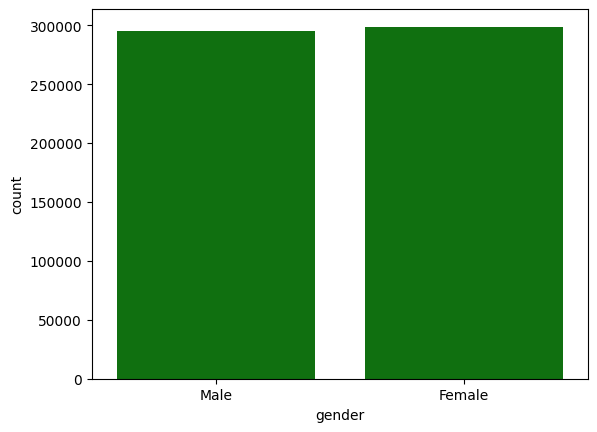

In [24]:
sns.countplot(x=train['gender'], color = 'green')

<Axes: xlabel='Churn', ylabel='count'>

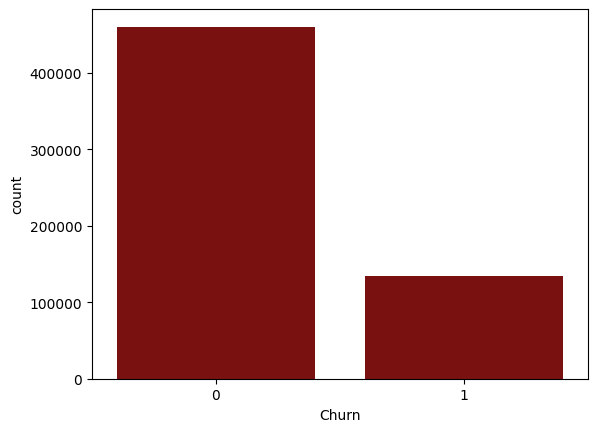

In [25]:
sns.countplot(x=y, color = 'darkred')

In [26]:
def plot_histogram(train, column_name):

  plt.figure(figsize=(5, 3))
  sns.histplot(train[column_name], kde=True)
  plt.title(f"Distribution of {column_name}")

  # calculate the mean and median values for the columns
  col_mean = train[column_name].mean()
  col_median = train[column_name].median()

  # add vertical lines for mean and median
  plt.axvline(col_mean, color="red", linestyle="--", label="Mean")
  plt.axvline(col_median, color="green", linestyle="-", label="Median")

  plt.legend()

  plt.show()

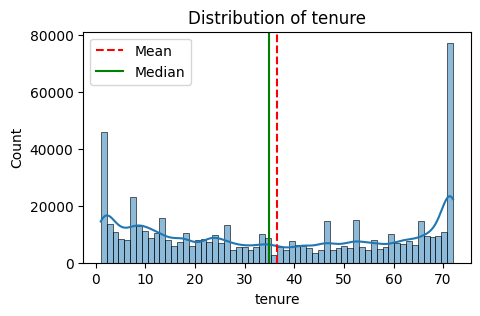

In [27]:
plot_histogram(train, "tenure")

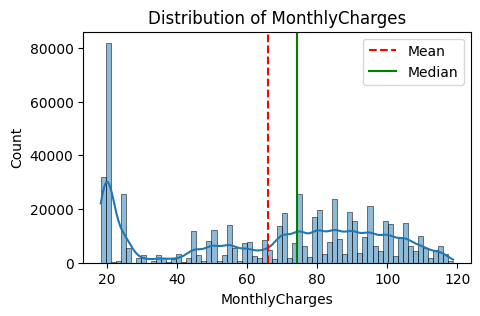

In [28]:
plot_histogram(train, "MonthlyCharges")


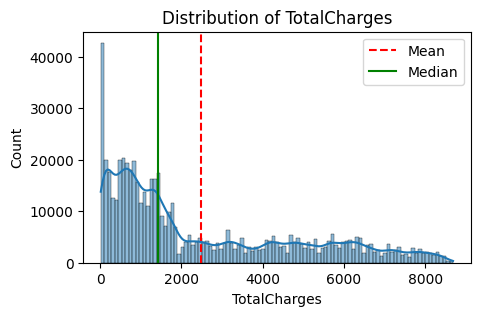

In [29]:
plot_histogram(train, "TotalCharges")

**Box Plot**

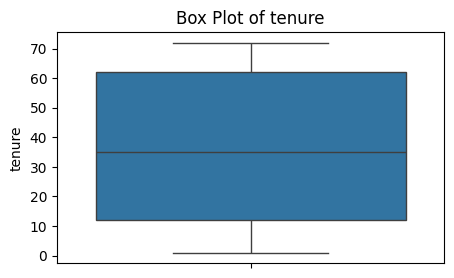

In [30]:
def plot_boxplot(train, column_name):

  plt.figure(figsize=(5, 3))
  sns.boxplot(y=train[column_name])
  plt.title(f"Box Plot of {column_name}")
  plt.ylabel(column_name)
  plt.show
plot_boxplot(train, "tenure")

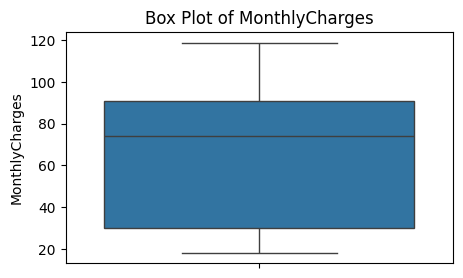

In [31]:
plot_boxplot(train, "MonthlyCharges")

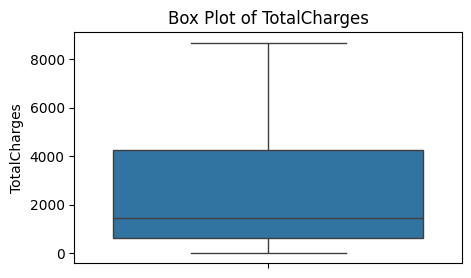

In [32]:
plot_boxplot(train, "TotalCharges")

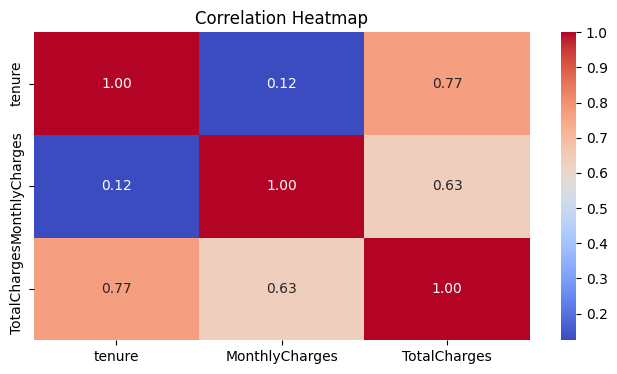

In [33]:
# correlation matrix - heatmap
plt.figure(figsize=(8, 4))
sns.heatmap(train[["tenure", "MonthlyCharges", "TotalCharges"]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

**Count Plot**

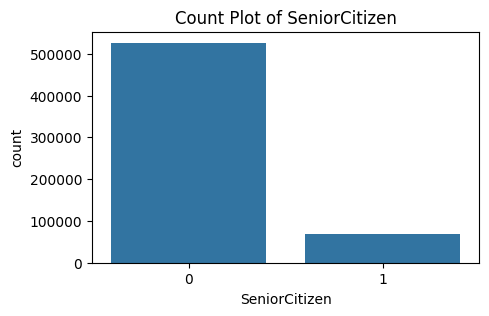

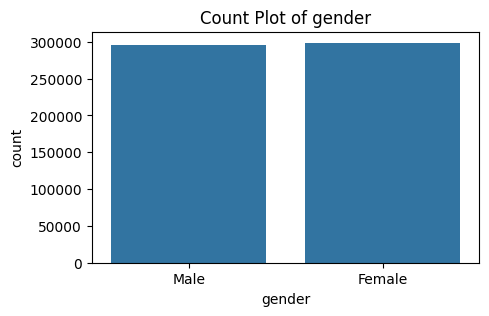

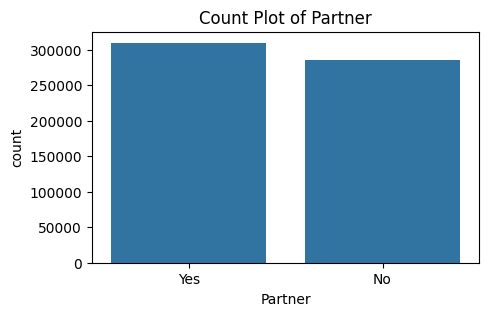

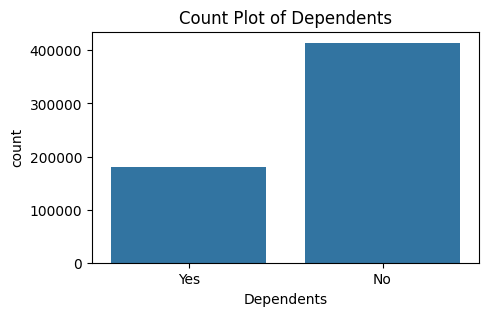

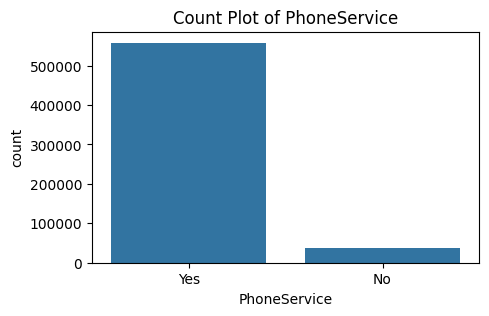

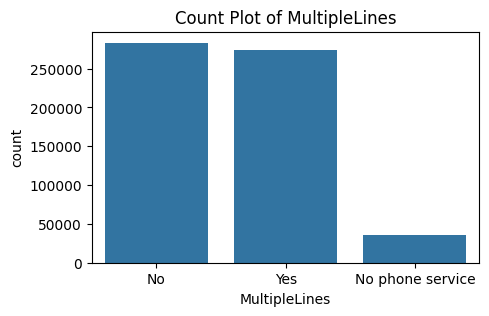

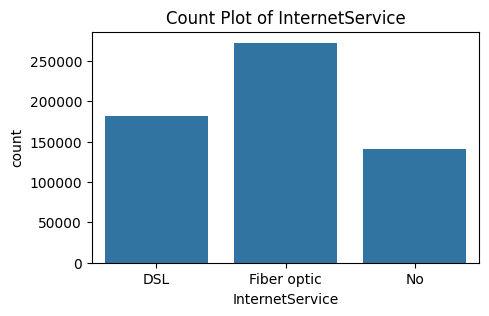

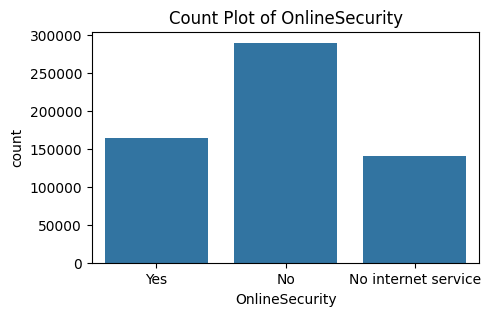

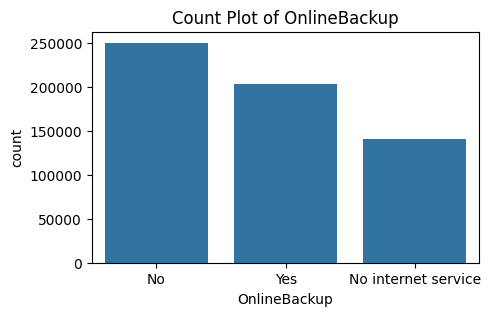

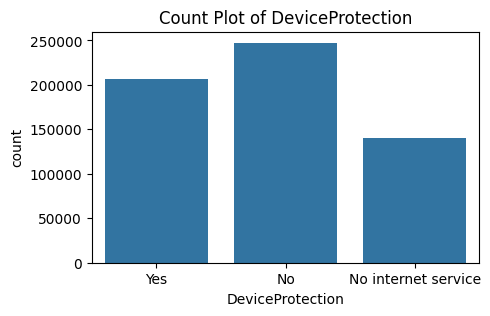

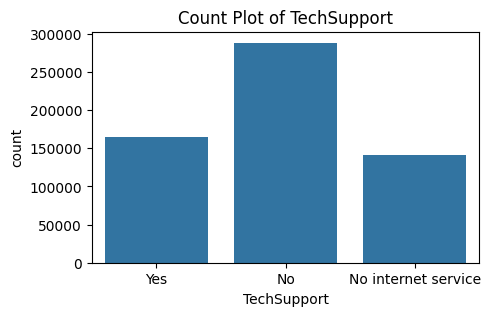

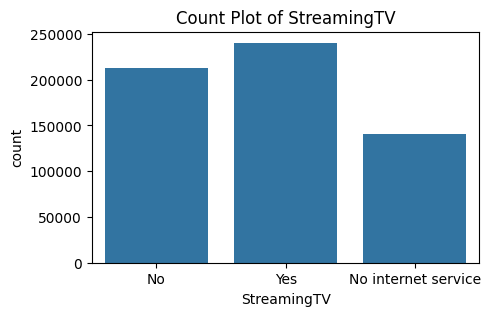

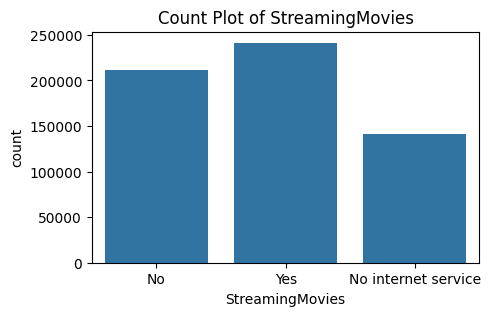

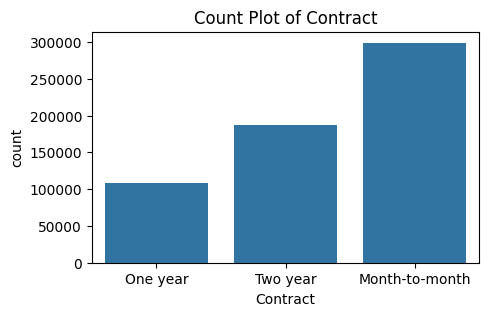

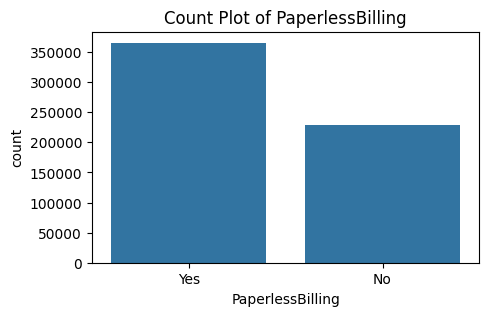

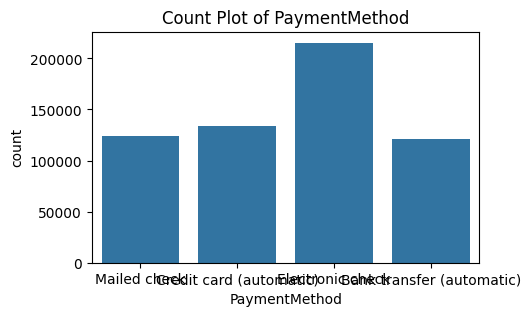

In [34]:
object_cols = train.select_dtypes(include="object").columns.to_list()

object_cols = ["SeniorCitizen"] + object_cols

for col in object_cols:
  plt.figure(figsize=(5, 3))
  sns.countplot(x=train[col])
  plt.title(f"Count Plot of {col}")
  plt.show()

## PreProcessing

In [35]:
train.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20
2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35
3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70
4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45


In [36]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   gender            594194 non-null  object 
 1   SeniorCitizen     594194 non-null  int64  
 2   Partner           594194 non-null  object 
 3   Dependents        594194 non-null  object 
 4   tenure            594194 non-null  int64  
 5   PhoneService      594194 non-null  object 
 6   MultipleLines     594194 non-null  object 
 7   InternetService   594194 non-null  object 
 8   OnlineSecurity    594194 non-null  object 
 9   OnlineBackup      594194 non-null  object 
 10  DeviceProtection  594194 non-null  object 
 11  TechSupport       594194 non-null  object 
 12  StreamingTV       594194 non-null  object 
 13  StreamingMovies   594194 non-null  object 
 14  Contract          594194 non-null  object 
 15  PaperlessBilling  594194 non-null  object 
 16  PaymentMethod     59

### Label Encoding

In [37]:
object_columns = train.select_dtypes(include="object").columns
encoders = {}

In [38]:
for column in object_columns:
    le = LabelEncoder()
    # for Train
    train[column] = le.fit_transform(train[column])
    
    # for test
    test[column] = le.transform(test[column])
    
    encoders[column] = le

print("Label encoded!")

Label encoded!


In [39]:
encoders

{'gender': LabelEncoder(),
 'Partner': LabelEncoder(),
 'Dependents': LabelEncoder(),
 'PhoneService': LabelEncoder(),
 'MultipleLines': LabelEncoder(),
 'InternetService': LabelEncoder(),
 'OnlineSecurity': LabelEncoder(),
 'OnlineBackup': LabelEncoder(),
 'DeviceProtection': LabelEncoder(),
 'TechSupport': LabelEncoder(),
 'StreamingTV': LabelEncoder(),
 'StreamingMovies': LabelEncoder(),
 'Contract': LabelEncoder(),
 'PaperlessBilling': LabelEncoder(),
 'PaymentMethod': LabelEncoder()}

In [40]:
train.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,1,0,1,1,29,1,0,0,2,0,2,2,0,0,1,1,3,60.10,1653.85
1,1,0,1,1,58,1,0,0,2,2,0,2,2,0,2,0,1,69.50,3778.20
2,1,0,1,0,58,1,2,1,0,2,0,0,2,2,0,1,2,100.40,5841.35
3,0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,1,2,69.70,70.70
4,0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,1,2,70.45,70.45


In [41]:
test.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0,0,1,0,72,1,2,1,2,2,2,2,2,2,2,1,2,115.55,8061.50
1,0,0,1,0,71,1,0,2,1,1,1,1,1,1,2,0,0,19.80,1336.50
2,1,0,0,0,12,1,0,0,2,2,0,0,0,0,0,1,0,55.55,633.55
3,1,0,1,1,71,1,2,0,2,0,2,2,2,2,2,0,1,84.10,6457.15
4,0,0,0,0,15,1,0,1,2,0,0,0,2,2,0,0,2,90.35,1233.65


### Train-Test Split

In [42]:
# # splitting the features and target
X = train
y 

0         0
1         0
2         0
3         1
4         1
         ..
594189    0
594190    0
594191    0
594192    0
594193    1
Name: Churn, Length: 594194, dtype: int64

In [43]:
# split training and test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [44]:
print("X_train shape: ", X_train.shape)
print("X_test shape: ", X_test.shape)
print("y_train shape: ", y_train.shape)
print("y_test shape: ", y_test.shape)

X_train shape:  (475355, 19)
X_test shape:  (118839, 19)
y_train shape:  (475355,)
y_test shape:  (118839,)


In [45]:
y_train.shape

(475355,)

### Synthetic Minority Oversampling Technique (SMOTE)

In [46]:
X_train_fast = X_train.astype({col: 'float32' for col in X_train.select_dtypes('float64').columns})
X_train_fast = X_train_fast.astype({col: 'int32' for col in X_train_fast.select_dtypes('int64').columns})

In [47]:
smote = SMOTE(random_state=42)

In [48]:
X_train_smote, y_train_smote = smote.fit_resample(X_train_fast, y_train)

In [49]:
print("-" * 30)
print(f" SMOTE done!")
print(f"New X_train shape: {X_train_smote.shape}")
print(f"Target Distribution:\n{y_train_smote.value_counts()}")
print("-" * 30)

------------------------------
 SMOTE done!
New X_train shape: (736884, 19)
Target Distribution:
Churn
0    368442
1    368442
Name: count, dtype: int64
------------------------------


### Model Training

In [50]:
# dictionary of models
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_jobs=-1, random_state=42),
    "XGBoost": XGBClassifier(tree_method='hist', device="cuda", random_state=42), # Use 'hist' for speed!
    "LightGBM": LGBMClassifier(n_estimators=500, learning_rate=0.05, random_state=42)
}

In [51]:
cv_results = {}

In [52]:
warnings.filterwarnings('ignore')

for model_name, model in models.items():
    print(f" Training on : {model_name}....")

    scores = cross_val_score(model, X_train_smote, y_train_smote, cv = 5, scoring = "roc_auc", n_jobs = -1)
    cv_results[model_name] = scores
    print(f"✅ {model_name} Mean ROC-AUC: {np.mean(scores):.4f} (+/- {np.std(scores):.4f})")
    print("-" * 50)

 Training on : Decision Tree....
✅ Decision Tree Mean ROC-AUC: 0.8477 (+/- 0.0466)
--------------------------------------------------
 Training on : Random Forest....
✅ Random Forest Mean ROC-AUC: 0.9543 (+/- 0.0254)
--------------------------------------------------
 Training on : XGBoost....


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:774: UserWarning: [09:36:48] WARNING: /workspace/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)
/usr/local/lib/python3.12/dist-packages/xgboost/core.py:774: UserWarning: [09:36:48] WARNING: /workspace/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before

✅ XGBoost Mean ROC-AUC: 0.9506 (+/- 0.0267)
--------------------------------------------------
 Training on : LightGBM....
✅ LightGBM Mean ROC-AUC: 0.9502 (+/- 0.0261)
--------------------------------------------------


### Evaltuations

#### RandomForestClassifier

In [53]:
# best_model = RandomForestClassifier(n_jobs=-1, random_state=42)
best_model = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_leaf=5)
best_model.fit(X_train_smote, y_train_smote)

rfc_probs = best_model.predict_proba(test)[:, 1]

submission = pd.DataFrame({
    'id': test_ids,
    'Churn': rfc_probs
})

submission.to_csv('submission_rfc.csv', index=False)
print("file  created!")

file  created!


In [54]:
submission.head()

,id,Churn
0,594194,0.108391
1,594195,0.005995
2,594196,0.257554
3,594197,0.007157
4,594198,0.718764


In [55]:
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

# 2. Calculate the scores 📊
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"🎯 Test Accuracy: {accuracy:.4f}")
print(f"📈 Test ROC-AUC: {roc_auc:.4f}")
print("-" * 30)

# 3. Detailed Report (Shows Precision and Recall for Churners) 📝
print("Classification Report:")
print(classification_report(y_test, y_pred))

🎯 Test Accuracy: 0.8220
📈 Test ROC-AUC: 0.9062
------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.82      0.88     91935
           1       0.57      0.84      0.68     26904

    accuracy                           0.82    118839
   macro avg       0.76      0.83      0.78    118839
weighted avg       0.86      0.82      0.83    118839



#### XGBClassifier 

In [56]:
# xgb_model = XGBClassifier(tree_method='hist', random_state=42)
xgb_model = XGBClassifier(reg_alpha=0.1, reg_lambda=1.0, learning_rate=0.01)
xgb_model.fit(X_train_smote, y_train_smote)

xgb_probs = xgb_model.predict_proba(test)[:, 1]

submission_xgb = pd.DataFrame({
    'id': test_ids,
    'Churn': xgb_probs
})

submission_xgb.to_csv('submission_xgb.csv', index=False)

print(" submission_xgb.csv' created !")
submission_xgb.head()

 submission_xgb.csv' created !


,id,Churn
0,594194,0.241711
1,594195,0.185130
2,594196,0.354616
3,594197,0.187379
4,594198,0.699251


In [57]:
y_pred = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"🎯 Test Accuracy: {accuracy:.4f}")
print(f"📈 Test ROC-AUC: {roc_auc:.4f}")
print("-" * 30)

print("Classification Report:")
print(classification_report(y_test, y_pred))

🎯 Test Accuracy: 0.8125
📈 Test ROC-AUC: 0.9034
------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.80      0.87     91935
           1       0.56      0.85      0.67     26904

    accuracy                           0.81    118839
   macro avg       0.75      0.83      0.77    118839
weighted avg       0.86      0.81      0.82    118839



#### LGBMClassifier 

In [58]:
lgbm_model = LGBMClassifier(n_estimators=500, learning_rate=0.05, random_state=42, n_jobs=-1)
lgbm_model.fit(X_train_smote, y_train_smote)

lgbm_probs = lgbm_model.predict_proba(test)[:, 1]

submission_lgbm = pd.DataFrame({'id': test_ids, 'Churn': lgbm_probs})
submission_lgbm.to_csv('submission_lgbm.csv', index=False)

print("'submission_lgbm.csv' created!")

[LightGBM] [Info] Number of positive: 368442, number of negative: 368442
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.053907 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 626
[LightGBM] [Info] Number of data points in the train set: 736884, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
'submission_lgbm.csv' created!


In [59]:
y_pred = lgbm_model.predict(X_test)
y_pred_proba = lgbm_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"🎯 Test Accuracy: {accuracy:.4f}")
print(f"📈 Test ROC-AUC: {roc_auc:.4f}")
print("-" * 30)

print("Classification Report:")
print(classification_report(y_test, y_pred))

🎯 Test Accuracy: 0.8420
📈 Test ROC-AUC: 0.9093
------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.86      0.89     91935
           1       0.62      0.78      0.69     26904

    accuracy                           0.84    118839
   macro avg       0.78      0.82      0.79    118839
weighted avg       0.86      0.84      0.85    118839



In [60]:
final_ensemble_probs = (rfc_probs * 0.4) + (xgb_probs * 0.3) + (lgbm_probs * 0.3)

submission_final = pd.DataFrame({
    'id': test_ids,
    'Churn': final_ensemble_probs
})

submission_final.to_csv('submission_ensemble_master.csv', index=False)

print("Ensemble Submission!")
print(submission_final.head())

Ensemble Submission!
       id     Churn
0  594194  0.153016
1  594195  0.058405
2  594196  0.244624
3  594197  0.060928
4  594198  0.712757
